# 2. Training

Two YOLOv12n models, fine-tuned from COCO-pretrained weights on the combined dataset: one for 6 classes (fresh or rotten apple, banana, orange) and one for 3 (just the fruit). Both ran 50 epochs at 640 px, batch 8, on an RTX 3090 under WSL. Augmentation is Ultralytics' default: HSV colour jitter, translation, scaling, horizontal flips and 4-photo mosaics, with mosaic switched off for the last 10 epochs. The best epoch is picked on the validation split; the test split isn't touched until notebook 3.

Training takes a couple of hours per model, so it only runs here with `TRAIN = True`. The rest of the notebook reads the finished runs. Both runs were interrupted and resumed from their last checkpoint, which picks up the weights, optimizer state and learning-rate schedule where they stopped.

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path[:0] = [os.getcwd(), "notebooks"]

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from ultralytics import YOLO

import viz
from train import AUGMENT  # hsv_h, hsv_s, hsv_v, translate, scale, fliplr, mosaic, close_mosaic

viz.setup()
TRAIN = False
if TRAIN:
    for data, name in (("datasets/combined/data.yaml", "fruit-6class"), ("datasets/combined-3class/data.yaml", "fruit-3class")):
        YOLO("yolo12n.pt").train(data=data, epochs=50, imgsz=640, batch=8, workers=8, name=name, **AUGMENT)

runs = {"6 classes": Path("runs/detect/fruit-6class"), "3 classes": Path("runs/detect/fruit-3class")}
keys = ("epochs", "imgsz", "batch", "optimizer", "hsv_h", "hsv_s", "hsv_v", "translate", "scale", "fliplr", "mosaic", "close_mosaic")
pd.DataFrame({k: [yaml.safe_load((run / "args.yaml").read_text())[key] for key in keys] for k, run in runs.items()}, index=keys)

,6 classes,3 classes
epochs,50,50
imgsz,640,640
batch,8,8
optimizer,auto,auto
hsv_h,0.015,0.015
hsv_s,0.7,0.7
hsv_v,0.4,0.4
translate,0.1,0.1
scale,0.5,0.5
fliplr,0.5,0.5


One training batch after augmentation, from the 6-class run. The numbers are class ids (0-2 rotten apple, banana, orange; 3-5 fresh); photos without boxes are faces and scenes.

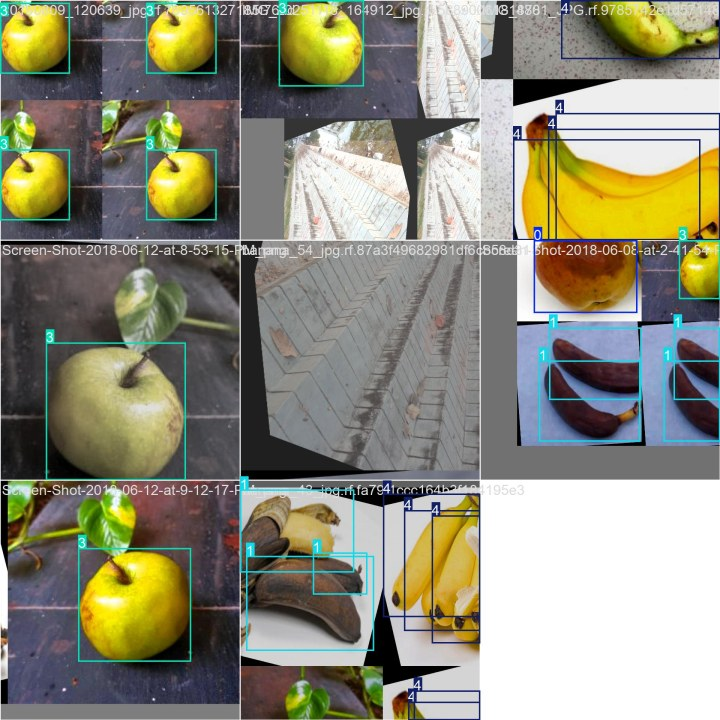

In [2]:
viz.show(runs["6 classes"] / "train_batch0.jpg", width=720)

## Curves

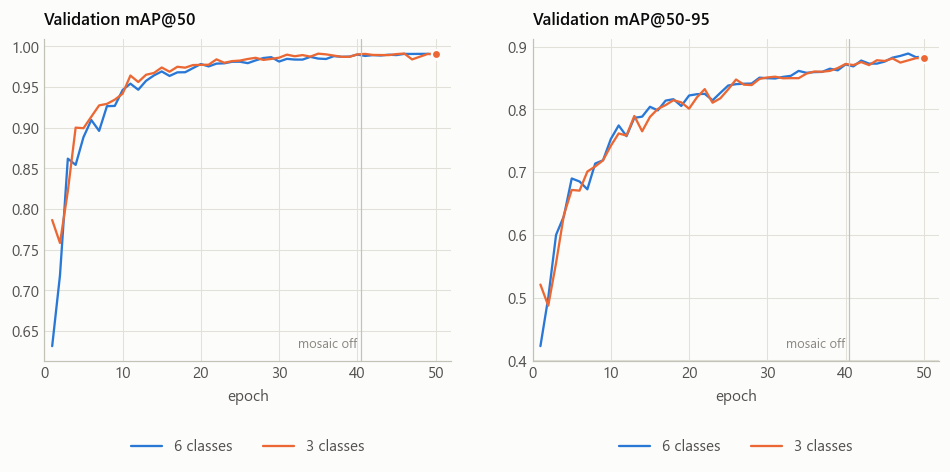

6 classes: best epoch 48, validation mAP@50 0.991, mAP@50-95 0.889
3 classes: best epoch 50, validation mAP@50 0.990, mAP@50-95 0.882


In [3]:
logs = {k: pd.read_csv(f"results/training_fruit-{k[0]}class.csv") for k in runs}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, col, title in ((axes[0], "metrics/mAP50(B)", "Validation mAP@50"), (axes[1], "metrics/mAP50-95(B)", "Validation mAP@50-95")):
    for (label, log), color in zip(logs.items(), (viz.BLUE, viz.ORANGE)):
        ax.plot(log.epoch, log[col], color=color, label=label)
        ax.plot(log.epoch.iloc[-1], log[col].iloc[-1], "o", color=color, ms=6, mec=viz.SURFACE, mew=1.5)
    ax.axvline(40.5, color=viz.AXIS, lw=0.8)
    ax.text(40, 0.03, "mosaic off", transform=ax.get_xaxis_transform(), ha="right", va="bottom", fontsize=8.5, color=viz.MUTED)
    ax.set(title=title, xlabel="epoch", xlim=(0, 52))
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
viz.render(fig)

for label, log in logs.items():
    best = log.loc[log["metrics/mAP50-95(B)"].idxmax()]
    print(f"{label}: best epoch {int(best.epoch)}, validation mAP@50 {best['metrics/mAP50(B)']:.3f}, "
          f"mAP@50-95 {best['metrics/mAP50-95(B)']:.3f}")

Both models were still improving slowly at the end, mostly in box precision (mAP@50-95). The 3-class log has no row for epoch 48, which was lost when that run was interrupted.

The best epochs' weights are the released models, `models/fruit-6class.pt` and `models/fruit-3class.pt`.